# Audio Modal Contribution Experiment

> **Research Question**: Does acoustic emotional expression (prosody via `voice_settings`) contribute independent information to multimodal sentiment/intention classification, or is it dominated by the visual and text modalities?

## Experimental Design
- **Fixed**: image + script text (same semantic content)
- **Varied**: `voice_settings` (stability × style grid) → different prosody
- **Measured**: Does the tri-modal fusion classification change across audio variants?

## Pipeline
1. Generate N audio variants per script (ElevenLabs, `stability × style` grid)
2. Extract embeddings: ImageBind (Vision + Text), Emotion2Vec (Audio)
3. Late fusion: concat embeddings → zero-shot cosine similarity classification
4. Analyze: does audio modality shift the prediction, or is it suppressed by V+T?

## Cell 1: Setup

In [20]:
!pip -q install datasets pandas numpy pillow tqdm requests soundfile librosa
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# Emotion2Vec via modelscope
!pip -q install modelscope funasr
# ImageBind (install from source if not already)
import subprocess, sys
try:
    import imagebind
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/facebookresearch/ImageBind.git"], check=True)

In [21]:
import os
from pathlib import Path

# Load API key from .env file if present, otherwise fall back to shell environment
def _load_dotenv(path=".env"):
    p = Path(path)
    if not p.exists():
        p = Path.home() / ".env"
    if p.exists():
        for line in p.read_text().splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, _, v = line.partition("=")
                os.environ.setdefault(k.strip(), v.strip())

_load_dotenv()

# Colab fallback (no-op when running locally)
try:
    from google.colab import userdata
    for k in ['ELEVENLABS_API_KEY']:
        v = userdata.get(k)
        if v:
            os.environ[k] = v
except ImportError:
    pass

for k in ['ELEVENLABS_API_KEY']:
    print(f"{k}: {'set' if os.getenv(k) else 'MISSING — set in .env or: export ELEVENLABS_API_KEY=sk-...'}")

ELEVENLABS_API_KEY: set


## Cell 2: Load Metadata & Fix Paths

In [23]:
from pathlib import Path
import pandas as pd

# ── REPO_ROOT: absolute path to the repo root ────────────────────────────────
REPO_ROOT = Path("/Users/ruyiyang/Documents/courseware/2026_Spring/mas60/mmai_project/MMAI-MemeSonic")
# ─────────────────────────────────────────────────────────────────────────────
assert REPO_ROOT.exists(), f"REPO_ROOT not found: {REPO_ROOT}"
print("REPO_ROOT:", REPO_ROOT)

CSV_CANDIDATES = [
    REPO_ROOT / "data/metadata/results_100_samples_rescripted_en.csv",
    REPO_ROOT / "data/metadata/results_100_samples.csv",
]
csv_path = next((p for p in CSV_CANDIDATES if p.exists()), None)
assert csv_path is not None, (
    "No CSV found. Expected one of:\n" + "\n".join(str(p) for p in CSV_CANDIDATES)
)

meta_df = pd.read_csv(csv_path)

# Rebuild local paths from repo structure (CSV paths point to Colab Drive)
meta_df["img_path"] = meta_df["id"].astype(int).map(
    lambda i: str(REPO_ROOT / "data/images" / f"{i:03d}.png")
)
meta_df["script_audio_ref"] = meta_df["id"].astype(int).map(
    lambda i: str(REPO_ROOT / "outputs/closed/script" / f"{i:03d}_script.mp3")
)

assert "script" in meta_df.columns, "'script' column missing from CSV."
meta_df["script"] = meta_df["script"].fillna("").astype(str)

# Filter to rows with images present (script_audio_ref is optional for this experiment)
n_before = len(meta_df)
meta_df = meta_df[meta_df["img_path"].map(lambda p: Path(p).exists())].reset_index(drop=True)
print(f"Loaded {len(meta_df)} / {n_before} rows (images found)")
print(f"Sentiment distribution:\n{meta_df['sentiment'].value_counts()}")
print(f"Intention distribution:\n{meta_df['intention'].value_counts()}")
meta_df[["id", "sentiment", "intention", "script"]].head(5)

REPO_ROOT: /Users/ruyiyang/Documents/courseware/2026_Spring/mas60/mmai_project/MMAI-MemeSonic
Loaded 100 / 100 rows (images found)
Sentiment distribution:
sentiment
happiness    33
sorrow       24
love         16
anger         9
surprise      7
hate          6
fear          5
Name: count, dtype: int64
Intention distribution:
intention
entertaining    39
expressive      36
offensive       17
interactive      8
Name: count, dtype: int64


,id,sentiment,intention,script
0,0,happiness,entertaining,"I saw now calmly, hey there, got a meme to sha..."
1,1,love,entertaining,"Cheerfully, some magicians can walk on water, ..."
2,2,love,expressive,"Cheerfully, my heart's door is always open, bu..."
3,3,fear,entertaining,"Nervously. Uh-oh, I have no clue who you are. ..."
4,4,sorrow,expressive,"Sadly, wishing for a peaceful, snowy Christmas..."


## Cell 3: Generate Voice Settings Grid Audio (ElevenLabs)

For each script we generate **9 audio variants** covering the `stability × style` space.
Output path: `outputs/prosody_grid/{id:03d}_s{stability_idx}_st{style_idx}.mp3`

In [24]:
import itertools

# Fix one voice to isolate prosody as the only variable across grid settings.
# Using a voice from your ElevenLabs account (verified available):
VOICE_ID = "cgSgspJ2msm6clMCkdW9"  # Jessica - Playful, Bright, Warm
MODEL_ID  = "eleven_multilingual_v2"

# stability × style grid  (3×3 = 9 variants per script)
STABILITY_VALUES = [0.2, 0.5, 0.8]
STYLE_VALUES     = [0.2, 0.5, 0.8]
GRID = list(itertools.product(STABILITY_VALUES, STYLE_VALUES))

def setting_label(stab, style):
    s_tag  = {0.2: "low",  0.5: "mid",  0.8: "high"}[stab]
    st_tag = {0.2: "low",  0.5: "mid",  0.8: "high"}[style]
    return f"stab{s_tag}_style{st_tag}"

GRID_LABELS = [setting_label(s, st) for s, st in GRID]
print("Voice:", VOICE_ID, "(Jessica)")
print("Grid settings:")
for label, (s, st) in zip(GRID_LABELS, GRID):
    print(f"  {label:25s}  stability={s}  style={st}")

Voice: cgSgspJ2msm6clMCkdW9 (Jessica)
Grid settings:
  stablow_stylelow           stability=0.2  style=0.2
  stablow_stylemid           stability=0.2  style=0.5
  stablow_stylehigh          stability=0.2  style=0.8
  stabmid_stylelow           stability=0.5  style=0.2
  stabmid_stylemid           stability=0.5  style=0.5
  stabmid_stylehigh          stability=0.5  style=0.8
  stabhigh_stylelow          stability=0.8  style=0.2
  stabhigh_stylemid          stability=0.8  style=0.5
  stabhigh_stylehigh         stability=0.8  style=0.8


In [40]:
import requests
import time
from tqdm import tqdm

GRID_DIR = REPO_ROOT / "outputs" / "prosody_grid"
GRID_DIR.mkdir(parents=True, exist_ok=True)

ELEVENLABS_API_KEY = os.environ["ELEVENLABS_API_KEY"]

def eleven_tts(text: str, stability: float, style: float, out_path: Path):
    """Call ElevenLabs TTS and save mp3. Skip if file already exists."""
    if out_path.exists() and out_path.stat().st_size > 0:
        return  # already generated
    url = f"https://api.elevenlabs.io/v1/text-to-speech/{VOICE_ID}?output_format=mp3_44100_128"
    payload = {
        "text": text,
        "model_id": MODEL_ID,
        "voice_settings": {
            "stability": stability,
            "similarity_boost": 0.75,
            "style": style,
            "use_speaker_boost": True,
        },
    }
    headers = {"xi-api-key": ELEVENLABS_API_KEY, "Content-Type": "application/json"}
    r = requests.post(url, headers=headers, json=payload, timeout=120)
    r.raise_for_status()
    out_path.write_bytes(r.content)

# Generate grid — 100 scripts × 9 settings = 900 API calls total
# ElevenLabs free tier: ~10k chars/month. Each script ~30 words ≈ 150 chars → 900×150 = 135k chars.
# Use a paid/starter tier, or reduce to a subset below.
SUBSET_IDS = None  # set to e.g. list(range(20)) to test on first 20 samples

rows_to_process = meta_df if SUBSET_IDS is None else meta_df[meta_df["id"].isin(SUBSET_IDS)]

for _, row in tqdm(rows_to_process.iterrows(), total=len(rows_to_process), desc="Grid TTS"):
    sid = int(row["id"])
    text = str(row["script"]).strip()
    if not text:
        continue
    for label, (stab, style) in zip(GRID_LABELS, GRID):
        out_path = GRID_DIR / f"{sid:03d}_{label}.mp3"
        try:
            eleven_tts(text, stab, style, out_path)
        except Exception as e:
            print(f"  [WARN] id={sid} {label}: {e}")
        time.sleep(0.3)  # gentle rate-limit

print("Done. Generated files:", len(list(GRID_DIR.glob("*.mp3"))))

Grid TTS: 100%|██████████| 100/100 [11:01<00:00,  6.61s/it]

Done. Generated files: 900


## Cell 4: Extract Embeddings

- **Vision + Text** → ImageBind (frozen, pretrained)
- **Audio** → Emotion2Vec (pretrained on emotional speech data)

We extract V and T embeddings once per sample (they don't change across audio variants).
We extract A embeddings once per (sample, voice_setting) pair.

In [76]:
# ── Backbone selector ─────────────────────────────────────────────────────────
# Set BACKBONE = "imagebind" or "clip" to switch the vision-text encoder.
# Everything downstream (fusion, prototypes, projector) adapts automatically.
# BACKBONE = "imagebind"   # <── change to "clip" to use CLIP (ViT-L/14)
BACKBONE = "clip"
# ─────────────────────────────────────────────────────────────────────────────
print(f"Backbone: {BACKBONE}")

Backbone: clip


In [77]:
import os
import torch
import numpy as np
from pathlib import Path
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Pre-filter: keep only rows whose images can actually be opened by PIL
good_idx = []
for i, row in meta_df.iterrows():
    p = row["img_path"]
    try:
        Image.open(p).convert("RGB")
        good_idx.append(i)
    except Exception as e:
        print(f"[SKIP] id={row['id']} {p}: {e}")

valid_rows  = meta_df.loc[good_idx].reset_index(drop=True)
image_paths = valid_rows["img_path"].tolist()
text_list   = valid_rows["script"].tolist()
print(f"valid_rows: {len(valid_rows)}, image_paths: {len(image_paths)}")

if BACKBONE == "imagebind":
    from imagebind import data as ib_data
    from imagebind.models import imagebind_model
    from imagebind.models.imagebind_model import ModalityType

    vt_model = imagebind_model.imagebind_huge(pretrained=True)
    vt_model.eval().to(device)

    with torch.no_grad():
        inputs_vt = {
            ModalityType.VISION: ib_data.load_and_transform_vision_data(image_paths, device),
            ModalityType.TEXT:   ib_data.load_and_transform_text(text_list, device),
        }
        emb_vt = vt_model(inputs_vt)

    V_emb = torch.nn.functional.normalize(emb_vt[ModalityType.VISION], dim=-1).cpu().numpy()
    T_emb = torch.nn.functional.normalize(emb_vt[ModalityType.TEXT],   dim=-1).cpu().numpy()

    # expose encode_text helper for prototype cell
    def _encode_texts(texts):
        with torch.no_grad():
            inp = {ModalityType.TEXT: ib_data.load_and_transform_text(texts, device)}
            out = vt_model(inp)
        return torch.nn.functional.normalize(out[ModalityType.TEXT], dim=-1).cpu().numpy()

elif BACKBONE == "clip":
    import clip
    clip_model, clip_preprocess = clip.load("ViT-L/14", device=device)
    clip_model.eval()

    # Vision embeddings
    from torchvision import transforms
    imgs = torch.stack([
        clip_preprocess(Image.open(p).convert("RGB"))
        for p in image_paths
    ]).to(device)
    with torch.no_grad():
        V_emb = clip_model.encode_image(imgs).float()
    V_emb = torch.nn.functional.normalize(V_emb, dim=-1).cpu().numpy()

    # Text embeddings
    tokens = clip.tokenize(text_list, truncate=True).to(device)
    with torch.no_grad():
        T_emb = clip_model.encode_text(tokens).float()
    T_emb = torch.nn.functional.normalize(T_emb, dim=-1).cpu().numpy()

    # expose encode_text helper for prototype cell
    def _encode_texts(texts):
        toks = clip.tokenize(texts, truncate=True).to(device)
        with torch.no_grad():
            embs = clip_model.encode_text(toks).float()
        return torch.nn.functional.normalize(embs, dim=-1).cpu().numpy()

else:
    raise ValueError(f"Unknown BACKBONE: {BACKBONE!r}. Choose 'imagebind' or 'clip'.")

print(f"Vision embeddings: {V_emb.shape}")
print(f"Text   embeddings: {T_emb.shape}")

Device: cpu
valid_rows: 100, image_paths: 100
Vision embeddings: (100, 768)
Text   embeddings: (100, 768)


In [78]:
# Emotion2Vec via funasr / modelscope
# Paper: https://arxiv.org/abs/2312.15185
# Model: iic/emotion2vec_plus_large (trained on emotional speech, not env sounds)
from funasr import AutoModel

e2v_model = AutoModel(
    model="iic/emotion2vec_plus_large",
    hub="modelscope",
)

def get_emotion2vec_emb(audio_path: str) -> np.ndarray:
    """Return L2-normalized Emotion2Vec embedding for one audio file."""
    rec_result = e2v_model.generate(
        audio_path,
        output_dir=None,
        granularity="utterance",  # single vector per file
        extract_embedding=True,
    )
    emb = np.array(rec_result[0]["feats"])  # shape: (D,)
    emb = emb / (np.linalg.norm(emb) + 1e-8)
    return emb

# Test on one file
test_path = str(GRID_DIR / f"000_{GRID_LABELS[0]}.mp3")
if Path(test_path).exists():
    test_emb = get_emotion2vec_emb(test_path)
    print(f"Emotion2Vec embedding dim: {test_emb.shape}")
else:
    print("Run Cell 3 first to generate grid audio.")

funasr version: 1.3.1.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
You are using the latest version of funasr-1.3.1


Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /Users/ruyiyang/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /Users/ruyiyang/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /Users/ruyiyang/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /Users/ruyiyang/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /Users/ruyiyang/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.bias, /Users/ruyiyang/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.d

rtf_avg: 0.279: 100%|██████████| 1/1 [00:01<00:00,  1.42s/it]                                                                                      

Emotion2Vec embedding dim: (1024,)


In [41]:
# Extract Emotion2Vec embeddings for all (sample × voice_setting) pairs
# Result: A_emb_grid[label] = np.ndarray of shape (N, D_audio)

A_emb_grid = {}  # label -> (N, D)

for label in tqdm(GRID_LABELS, desc="Voice settings"):
    embs = []
    for _, row in valid_rows.iterrows():
        sid = int(row["id"])
        audio_path = str(GRID_DIR / f"{sid:03d}_{label}.mp3")
        if Path(audio_path).exists() and Path(audio_path).stat().st_size > 0:
            try:
                emb = get_emotion2vec_emb(audio_path)
            except Exception as e:
                print(f"  [WARN] {audio_path}: {e}")
                emb = np.zeros(test_emb.shape)
        else:
            emb = np.zeros(test_emb.shape)
        embs.append(emb)
    A_emb_grid[label] = np.stack(embs)  # (N, D_audio)

print("Audio embedding shapes:")
for k, v in A_emb_grid.items():
    print(f"  {k}: {v.shape}")

Voice settings: 100%|██████████| 9/9 [06:59<00:00, 46.56s/it]

Audio embedding shapes:
  stablow_stylelow: (100, 1024)
  stablow_stylemid: (100, 1024)
  stablow_stylehigh: (100, 1024)
  stabmid_stylelow: (100, 1024)
  stabmid_stylemid: (100, 1024)
  stabmid_stylehigh: (100, 1024)
  stabhigh_stylelow: (100, 1024)
  stabhigh_stylemid: (100, 1024)
  stabhigh_stylehigh: (100, 1024)


## Cell 5: Late Fusion & Zero-Shot Classification

**Fusion strategy**: L2-normalize each modality embedding, then weighted concatenation.

**Classification**: cosine similarity against text prototypes for each class.
No training needed — prototype vectors come from encoding class-label descriptions with ImageBind's text encoder.

We test 4 fusion configurations:
- `V` only
- `V + T`
- `V + T + A` (per voice_setting)

And compare results across the 9 voice settings to see if audio shifts the prediction.

In [79]:
# Build text prototype embeddings for each sentiment and intention class
# These act as "class anchors" in the shared embedding space.

SENTIMENT_PROTOTYPES = {
    "happiness": "a cheerful and joyful image with a happy tone",
    "love":      "a warm and loving image expressing affection",
    "anger":     "an intense and angry image expressing frustration",
    "sorrow":    "a sad and melancholy image expressing grief",
    "fear":      "a tense and fearful image expressing anxiety",
    "hate":      "a hostile image expressing strong dislike",
    "surprise":  "a surprising and unexpected image with astonishment",
}

INTENTION_PROTOTYPES = {
    "interactive":   "content inviting viewer interaction and engagement",
    "expressive":    "content conveying personal feelings and self-expression",
    "entertaining":  "humorous or entertaining content meant to amuse",
    "offensive":     "content that is provocative or potentially offensive",
    "other":         "content with unclear or mixed purpose",
}

def encode_text_prototypes(proto_dict: dict) -> dict:
    """Encode prototype strings with the selected backbone text encoder."""
    labels = list(proto_dict.keys())
    texts  = list(proto_dict.values())
    embs   = _encode_texts(texts)   # dispatches to ImageBind or CLIP
    return {label: emb for label, emb in zip(labels, embs)}

sent_protos  = encode_text_prototypes(SENTIMENT_PROTOTYPES)
int_protos   = encode_text_prototypes(INTENTION_PROTOTYPES)
sent_labels  = list(sent_protos.keys())
int_labels   = list(int_protos.keys())
sent_proto_mat = np.stack([sent_protos[l] for l in sent_labels])  # (C_s, D)
int_proto_mat  = np.stack([int_protos[l]  for l in int_labels])   # (C_i, D)

print(f"Sentiment prototypes: {sent_proto_mat.shape}  labels={sent_labels}")
print(f"Intention prototypes: {int_proto_mat.shape}   labels={int_labels}")

Sentiment prototypes: (7, 768)  labels=['happiness', 'love', 'anger', 'sorrow', 'fear', 'hate', 'surprise']
Intention prototypes: (5, 768)   labels=['interactive', 'expressive', 'entertaining', 'offensive', 'other']


In [80]:
def fuse_and_classify(
    v_emb: np.ndarray,        # (N, D_v)
    t_emb: np.ndarray,        # (N, D_t)
    a_emb: np.ndarray | None, # (N, D_a) or None
    proto_mat: np.ndarray,    # (C, D_fused)
    w_v: float = 1.0,
    w_t: float = 1.0,
    w_a: float = 1.0,
) -> np.ndarray:
    """
    Weighted late fusion then zero-shot classify.
    Returns predicted class indices (N,).

    NOTE: V, T embeddings are both ImageBind (D=1024) and already share the
    same space, so we average them before concatenating with A.
    A (Emotion2Vec) lives in a different space → concat after normalization.
    """
    # Combine V and T in ImageBind space (they are comparable)
    vt = (w_v * v_emb + w_t * t_emb) / (w_v + w_t)  # (N, D_vt)
    vt = vt / (np.linalg.norm(vt, axis=1, keepdims=True) + 1e-8)

    if a_emb is None:
        fused = vt  # (N, D_vt)
        # proto_mat must also be D_vt
        proto = proto_mat
    else:
        # Concat: [vt | a_emb * w_a]  then renormalize
        a_scaled = w_a * a_emb / (np.linalg.norm(a_emb, axis=1, keepdims=True) + 1e-8)
        fused = np.concatenate([vt, a_scaled], axis=1)  # (N, D_vt + D_a)
        fused = fused / (np.linalg.norm(fused, axis=1, keepdims=True) + 1e-8)
        # Extend prototypes with zero audio component for V+T baseline,
        # or use the full concat prototype. Here we use VT-only prototype
        # padded with zeros for the audio dims so cosine sim is computed fairly.
        D_a = a_emb.shape[1]
        proto_pad = np.concatenate(
            [proto_mat, np.zeros((proto_mat.shape[0], D_a))], axis=1
        )
        proto = proto_pad / (np.linalg.norm(proto_pad, axis=1, keepdims=True) + 1e-8)

    sim = fused @ proto.T  # (N, C)
    return sim.argmax(axis=1)  # (N,)


def accuracy(preds: np.ndarray, labels: list, gt_col: pd.Series) -> float:
    gt_idx = gt_col.map({l: i for i, l in enumerate(labels)}).values
    valid  = ~np.isnan(gt_idx.astype(float))
    return float((preds[valid] == gt_idx[valid]).mean())


print("Fusion functions defined.")

Fusion functions defined.


In [81]:
# Run classification under all configurations
results = []

gt_sent_col = valid_rows["sentiment"]
gt_int_col  = valid_rows["intention"]

# ── Baseline: V only ─────────────────────────────────────────────────────────
v_only_sent = fuse_and_classify(V_emb, T_emb, None, sent_proto_mat, w_v=1.0, w_t=0.0)
v_only_int  = fuse_and_classify(V_emb, T_emb, None, int_proto_mat,  w_v=1.0, w_t=0.0)
results.append({
    "config": "V_only",
    "sent_acc": accuracy(v_only_sent, sent_labels, gt_sent_col),
    "int_acc":  accuracy(v_only_int,  int_labels,  gt_int_col),
    "sent_preds": v_only_sent.tolist(),
    "int_preds":  v_only_int.tolist(),
})

# ── Baseline: V + T ───────────────────────────────────────────────────────────
vt_sent = fuse_and_classify(V_emb, T_emb, None, sent_proto_mat)
vt_int  = fuse_and_classify(V_emb, T_emb, None, int_proto_mat)
results.append({
    "config": "V+T",
    "sent_acc": accuracy(vt_sent, sent_labels, gt_sent_col),
    "int_acc":  accuracy(vt_int,  int_labels,  gt_int_col),
    "sent_preds": vt_sent.tolist(),
    "int_preds":  vt_int.tolist(),
})

# ── V + T + A for each voice setting ─────────────────────────────────────────
for grid_label, (stab, style) in zip(GRID_LABELS, GRID):
    A = A_emb_grid[grid_label]  # (N, D_a)
    vta_sent = fuse_and_classify(V_emb, T_emb, A, sent_proto_mat)
    vta_int  = fuse_and_classify(V_emb, T_emb, A, int_proto_mat)
    results.append({
        "config":    f"V+T+A ({grid_label})",
        "stability": stab,
        "style":     style,
        "sent_acc":  accuracy(vta_sent, sent_labels, gt_sent_col),
        "int_acc":   accuracy(vta_int,  int_labels,  gt_int_col),
        "sent_preds": vta_sent.tolist(),
        "int_preds":  vta_int.tolist(),
    })

results_df = pd.DataFrame(results)
print(results_df[["config", "sent_acc", "int_acc"]].to_string(index=False))

                    config  sent_acc  int_acc
                    V_only      0.26     0.43
                       V+T      0.32     0.47
  V+T+A (stablow_stylelow)      0.32     0.47
  V+T+A (stablow_stylemid)      0.32     0.47
 V+T+A (stablow_stylehigh)      0.32     0.47
  V+T+A (stabmid_stylelow)      0.32     0.47
  V+T+A (stabmid_stylemid)      0.32     0.47
 V+T+A (stabmid_stylehigh)      0.32     0.47
 V+T+A (stabhigh_stylelow)      0.32     0.47
 V+T+A (stabhigh_stylemid)      0.32     0.47
V+T+A (stabhigh_stylehigh)      0.32     0.47


## Cell 6: Analysis & Visualization

We answer the research question from multiple angles:

1. **Accuracy shift**: does adding audio improve/hurt classification vs V+T?
2. **Prediction flip rate**: for how many samples does the predicted label change across voice settings?
3. **Emotion2Vec space**: t-SNE of audio embeddings, colored by voice_setting and sentiment label.
4. **Heatmap**: stability × style → accuracy (sentiment and intention separately).

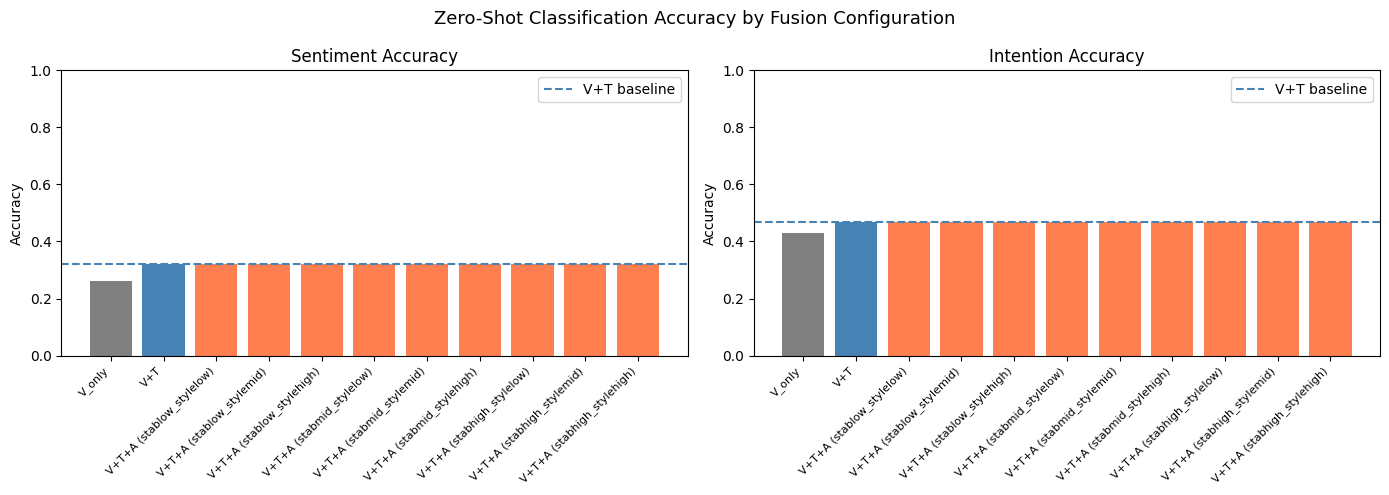

In [82]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ["sent_acc", "int_acc"], ["Sentiment Accuracy", "Intention Accuracy"]):
    configs = results_df["config"].tolist()
    accs    = results_df[metric].tolist()
    colors  = ["steelblue" if "V+T+A" not in c else "coral" for c in configs]
    colors[configs.index("V_only")] = "gray"

    bars = ax.bar(range(len(configs)), accs, color=colors)
    ax.axhline(results_df.loc[results_df["config"] == "V+T", metric].values[0],
               color="steelblue", linestyle="--", linewidth=1.5, label="V+T baseline")
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels(configs, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle("Zero-Shot Classification Accuracy by Fusion Configuration", fontsize=13)
plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "accuracy_by_config.png", dpi=150)
plt.show()

Samples where sentiment prediction flips across voice settings: 0.0%
Samples where intention prediction flips across voice settings: 0.0%


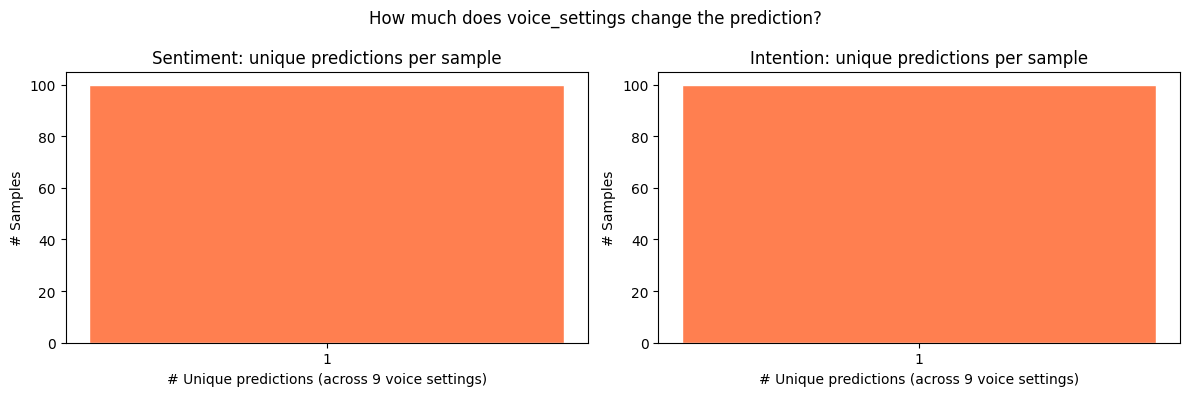

In [83]:
# Prediction flip rate across voice settings (per sample)
# For each sample, count how many unique sentiment predictions appear across the 9 voice settings.
# If always the same → audio has zero effect. If varies → audio is shifting predictions.

N = len(valid_rows)
grid_configs = [r for r in results if "V+T+A" in r["config"]]

sent_preds_grid = np.stack([r["sent_preds"] for r in grid_configs])  # (9, N)
int_preds_grid  = np.stack([r["int_preds"]  for r in grid_configs])  # (9, N)

# Number of unique predictions per sample across the 9 voice settings
sent_unique = np.array([len(set(sent_preds_grid[:, i])) for i in range(N)])
int_unique  = np.array([len(set(int_preds_grid[:,  i])) for i in range(N)])

flip_rate_sent = (sent_unique > 1).mean()
flip_rate_int  = (int_unique  > 1).mean()

print(f"Samples where sentiment prediction flips across voice settings: {flip_rate_sent:.1%}")
print(f"Samples where intention prediction flips across voice settings: {flip_rate_int:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, uniq, title in zip(axes,
                            [sent_unique, int_unique],
                            ["Sentiment: unique predictions per sample",
                             "Intention: unique predictions per sample"]):
    vals, counts = np.unique(uniq, return_counts=True)
    ax.bar(vals, counts, color="coral", edgecolor="white")
    ax.set_xlabel("# Unique predictions (across 9 voice settings)")
    ax.set_ylabel("# Samples")
    ax.set_title(title)
    ax.set_xticks(vals)

plt.suptitle("How much does voice_settings change the prediction?", fontsize=12)
plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "prediction_flip_rate.png", dpi=150)
plt.show()

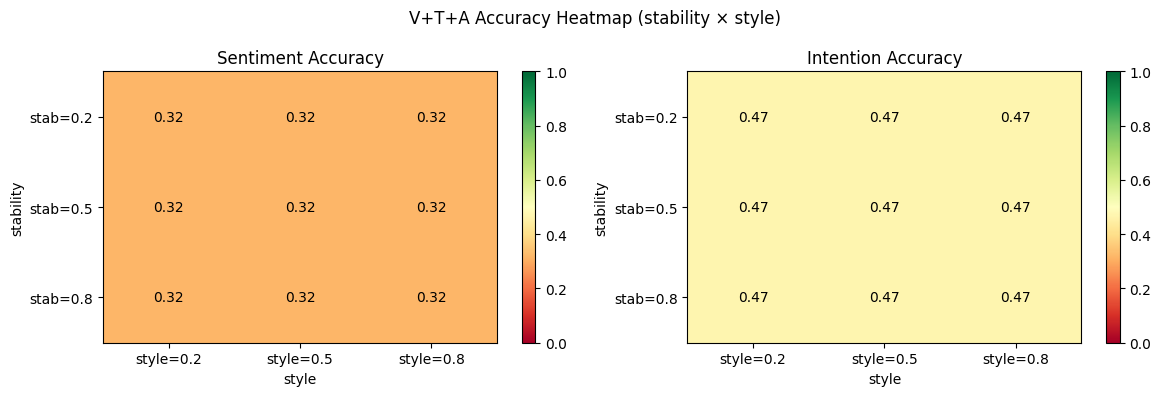

In [84]:
# Heatmap: stability × style → accuracy
import numpy as np

S_vals  = STABILITY_VALUES
ST_vals = STYLE_VALUES

sent_grid = np.zeros((len(S_vals), len(ST_vals)))
int_grid  = np.zeros((len(S_vals), len(ST_vals)))

for r in grid_configs:
    si  = S_vals.index(r["stability"])
    sti = ST_vals.index(r["style"])
    sent_grid[si, sti] = r["sent_acc"]
    int_grid[si,  sti] = r["int_acc"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, grid, title in zip(axes,
                             [sent_grid, int_grid],
                             ["Sentiment Accuracy", "Intention Accuracy"]):
    im = ax.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(ST_vals)))
    ax.set_xticklabels([f"style={v}" for v in ST_vals])
    ax.set_yticks(range(len(S_vals)))
    ax.set_yticklabels([f"stab={v}" for v in S_vals])
    ax.set_xlabel("style")
    ax.set_ylabel("stability")
    ax.set_title(title)
    for i in range(len(S_vals)):
        for j in range(len(ST_vals)):
            ax.text(j, i, f"{grid[i,j]:.2f}", ha="center", va="center",
                    color="black", fontsize=10)
    plt.colorbar(im, ax=ax)

plt.suptitle("V+T+A Accuracy Heatmap (stability × style)", fontsize=12)
plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "heatmap_stability_style.png", dpi=150)
plt.show()

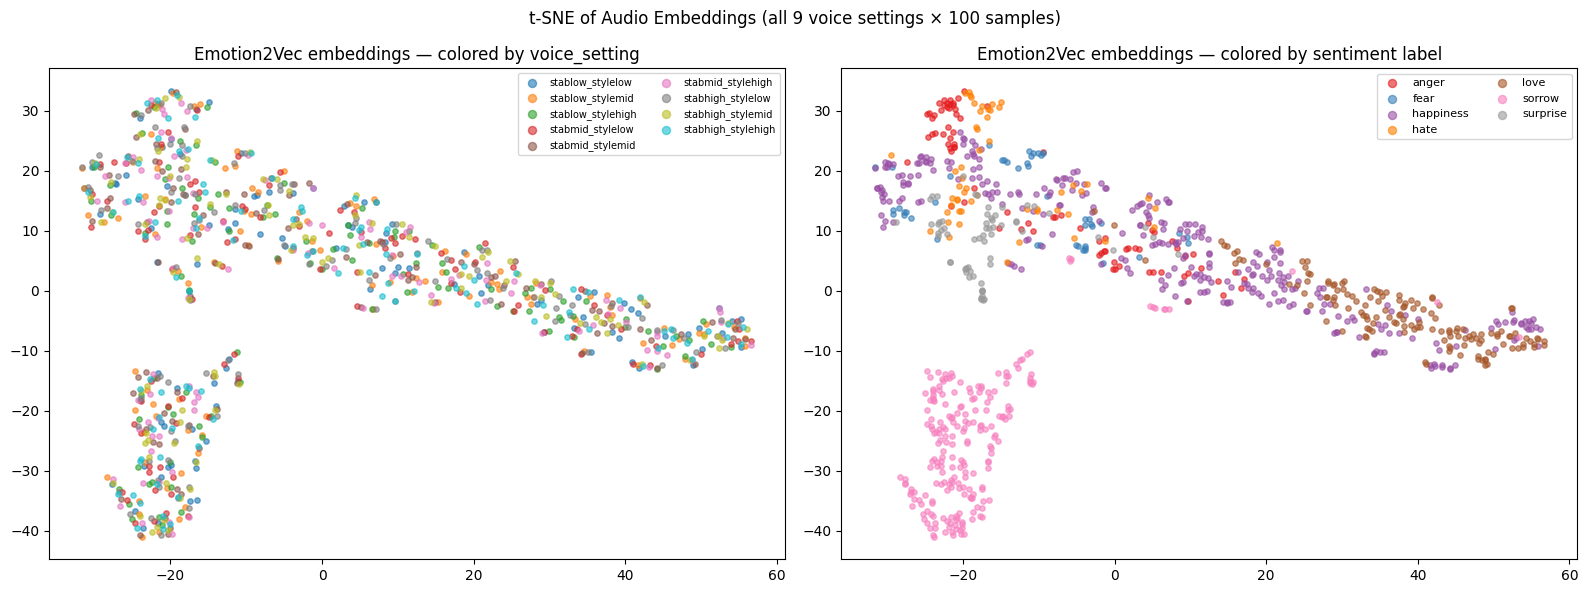

In [85]:
# t-SNE of Emotion2Vec audio embeddings
# Points colored by: (a) voice_setting label, (b) ground-truth sentiment
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

# Stack all embeddings: (9 settings × N samples, D_a)
all_audio_embs = np.concatenate([A_emb_grid[l] for l in GRID_LABELS], axis=0)
setting_tags   = np.repeat(np.arange(len(GRID_LABELS)), len(valid_rows))
sent_tags      = np.tile(valid_rows["sentiment"].values, len(GRID_LABELS))

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(all_audio_embs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: colored by voice_setting
cmap_s = cm.get_cmap("tab10", len(GRID_LABELS))
for i, label in enumerate(GRID_LABELS):
    mask = setting_tags == i
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=[cmap_s(i)], s=15, alpha=0.6, label=label)
axes[0].set_title("Emotion2Vec embeddings — colored by voice_setting")
axes[0].legend(fontsize=7, ncol=2, markerscale=1.5)

# Plot B: colored by sentiment label
unique_sents = sorted(set(sent_tags))
cmap_e = cm.get_cmap("Set1", len(unique_sents))
for i, sent in enumerate(unique_sents):
    mask = sent_tags == sent
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=[cmap_e(i)], s=15, alpha=0.6, label=sent)
axes[1].set_title("Emotion2Vec embeddings — colored by sentiment label")
axes[1].legend(fontsize=8, ncol=2, markerscale=1.5)

plt.suptitle("t-SNE of Audio Embeddings (all 9 voice settings × 100 samples)", fontsize=12)
plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "tsne_audio_embeddings.png", dpi=150)
plt.show()

# Key question to read from this plot:
# - If voice_setting points cluster together → prosody is a stronger signal than content
# - If sentiment points cluster together → content/semantics dominate in Emotion2Vec space

说明跟文字更相关，而不是跟语气更相关（在emotion2vec）


同一情感类别meme的音频（即使来自不同 voice_setting）在嵌入空间里比同一 voice_setting 的音频更相似。

In [86]:
# Quantify: intra-sentiment vs intra-setting distance in Emotion2Vec space
# If audio encodes sentiment: intra-sentiment distance < intra-setting distance
# If audio just reflects prosody style: intra-setting distance < intra-sentiment distance

def mean_pairwise_cosine_dist(embs: np.ndarray) -> float:
    """Mean cosine distance (1 - similarity) within a group."""
    if len(embs) < 2:
        return float("nan")
    norms = embs / (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-8)
    sim = norms @ norms.T
    upper = sim[np.triu_indices(len(sim), k=1)]
    return float(1 - upper.mean())

print("=== Intra-group cosine distance (lower = more similar within group) ===")
print("\n[By voice_setting]")
for grid_label in GRID_LABELS:
    embs = A_emb_grid[grid_label]
    d = mean_pairwise_cosine_dist(embs)
    print(f"  {grid_label:25s}: {d:.4f}")

print("\n[By sentiment label]")
all_embs_flat  = np.concatenate([A_emb_grid[l] for l in GRID_LABELS], axis=0)  # (9N, D)
all_sents_flat = np.tile(valid_rows["sentiment"].values, len(GRID_LABELS))
for sent_class in sorted(set(all_sents_flat)):
    embs = all_embs_flat[all_sents_flat == sent_class]
    d = mean_pairwise_cosine_dist(embs)
    print(f"  {sent_class:15s} (n={len(embs)}): {d:.4f}")

=== Intra-group cosine distance (lower = more similar within group) ===

[By voice_setting]
  stablow_stylelow         : 0.1718
  stablow_stylemid         : 0.1664
  stablow_stylehigh        : 0.1521
  stabmid_stylelow         : 0.1666
  stabmid_stylemid         : 0.1637
  stabmid_stylehigh        : 0.1726
  stabhigh_stylelow        : 0.1676
  stabhigh_stylemid        : 0.1700
  stabhigh_stylehigh       : 0.1717

[By sentiment label]
  anger           (n=81): 0.0514
  fear            (n=45): 0.0338
  happiness       (n=297): 0.1212
  hate            (n=54): 0.0343
  love            (n=144): 0.0494
  sorrow          (n=216): 0.0489
  surprise        (n=63): 0.1856


In [87]:
# Save all results
out_csv = REPO_ROOT / "outputs" / "modal_contribution_results.csv"
results_df[["config", "stability", "style", "sent_acc", "int_acc"]].to_csv(out_csv, index=False)
print("Saved:", out_csv)
print("\n=== Final Summary ===")
print(results_df[["config", "sent_acc", "int_acc"]].to_string(index=False))

Saved: /Users/ruyiyang/Documents/courseware/2026_Spring/mas60/mmai_project/MMAI-MemeSonic/outputs/modal_contribution_results.csv

=== Final Summary ===
                    config  sent_acc  int_acc
                    V_only      0.26     0.43
                       V+T      0.32     0.47
  V+T+A (stablow_stylelow)      0.32     0.47
  V+T+A (stablow_stylemid)      0.32     0.47
 V+T+A (stablow_stylehigh)      0.32     0.47
  V+T+A (stabmid_stylelow)      0.32     0.47
  V+T+A (stabmid_stylemid)      0.32     0.47
 V+T+A (stabmid_stylehigh)      0.32     0.47
 V+T+A (stabhigh_stylelow)      0.32     0.47
 V+T+A (stabhigh_stylemid)      0.32     0.47
V+T+A (stabhigh_stylehigh)      0.32     0.47


## Cell 7: RQ1 — Three-Way Emotion Distribution Comparison

We ask: **when audio is added, does it introduce new emotional signal (synergy), confirm image-text (redundancy), or contradict them (conflict)?**

Strategy:
- Project each modality's embeddings into a **shared emotion probability distribution** over the 7 sentiment classes via cosine similarity against the sentiment prototypes (soft-max).
- Plot the per-class marginal distributions for Image, Text, and Audio side by side.
- Compute cross-modal **KL divergence** and **cosine similarity** between pairs to quantify synergy/redundancy/conflict.

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.special import softmax
import warnings
warnings.filterwarnings("ignore")

TEMP = 0.05  # softmax temperature

def to_emotion_dist(emb: np.ndarray, proto_mat: np.ndarray, temp: float = TEMP) -> np.ndarray:
    """
    emb:       (N, D)  — L2-normalized embeddings
    proto_mat: (C, D)  — L2-normalized prototype embeddings
    returns:   (N, C)  — softmax emotion distributions
    """
    norms = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
    logits = norms @ proto_mat.T / temp
    return softmax(logits, axis=1)

# Guard: ensure sent_proto_mat matches current backbone dimension
assert sent_proto_mat.shape[1] == V_emb.shape[1], (
    f"Dimension mismatch: sent_proto_mat is {sent_proto_mat.shape[1]}-dim but V_emb is "
    f"{V_emb.shape[1]}-dim. Re-run the cell-prototypes cell after switching backbone."
)

# Build Emotion2Vec centroids per sentiment (data-driven, since Emotion2Vec has no text encoder)
all_audio_flat  = np.concatenate([A_emb_grid[l] for l in GRID_LABELS], axis=0)  # (9N, D)
all_sents_flat  = np.tile(valid_rows["sentiment"].values, len(GRID_LABELS))

e2v_centroids = {}
for sent_class in sent_labels:
    mask = all_sents_flat == sent_class
    if mask.sum() > 0:
        c = all_audio_flat[mask].mean(axis=0)
        e2v_centroids[sent_class] = c / (np.linalg.norm(c) + 1e-8)
    else:
        e2v_centroids[sent_class] = np.zeros(all_audio_flat.shape[1])

e2v_centroid_mat = np.stack([e2v_centroids[l] for l in sent_labels])  # (C, D_a)

# Mean audio embedding across 9 voice settings per sample
A_mean = np.stack([A_emb_grid[l] for l in GRID_LABELS]).mean(axis=0)  # (N, D_a)
A_mean = A_mean / (np.linalg.norm(A_mean, axis=1, keepdims=True) + 1e-8)

# Per-modality emotion distributions
dist_V = to_emotion_dist(V_emb, sent_proto_mat)       # (N, C)
dist_T = to_emotion_dist(T_emb, sent_proto_mat)       # (N, C)
dist_A = to_emotion_dist(A_mean, e2v_centroid_mat)    # (N, C) — Emotion2Vec space

print(f"Emotion distributions — V: {dist_V.shape}, T: {dist_T.shape}, A: {dist_A.shape}")
print(f"Example sample 0 distributions:")
for name, d in zip(["V", "T", "A"], [dist_V[0], dist_T[0], dist_A[0]]):
    top = sorted(zip(sent_labels, d), key=lambda x: -x[1])
    print(f"  {name}: " + "  ".join(f"{l}={v:.3f}" for l, v in top[:3]))

Emotion distributions — V: (100, 7), T: (100, 7), A: (100, 7)
Example sample 0 distributions:
  V: anger=0.166  surprise=0.160  happiness=0.155
  T: hate=0.305  surprise=0.196  love=0.111
  A: happiness=0.453  love=0.187  anger=0.113


Mean KL(V ↔ T): 0.1020 ± 0.0605
Mean KL(V ↔ A): 1.0583 ± 0.8927
Mean KL(T ↔ A): 0.9569 ± 0.9350


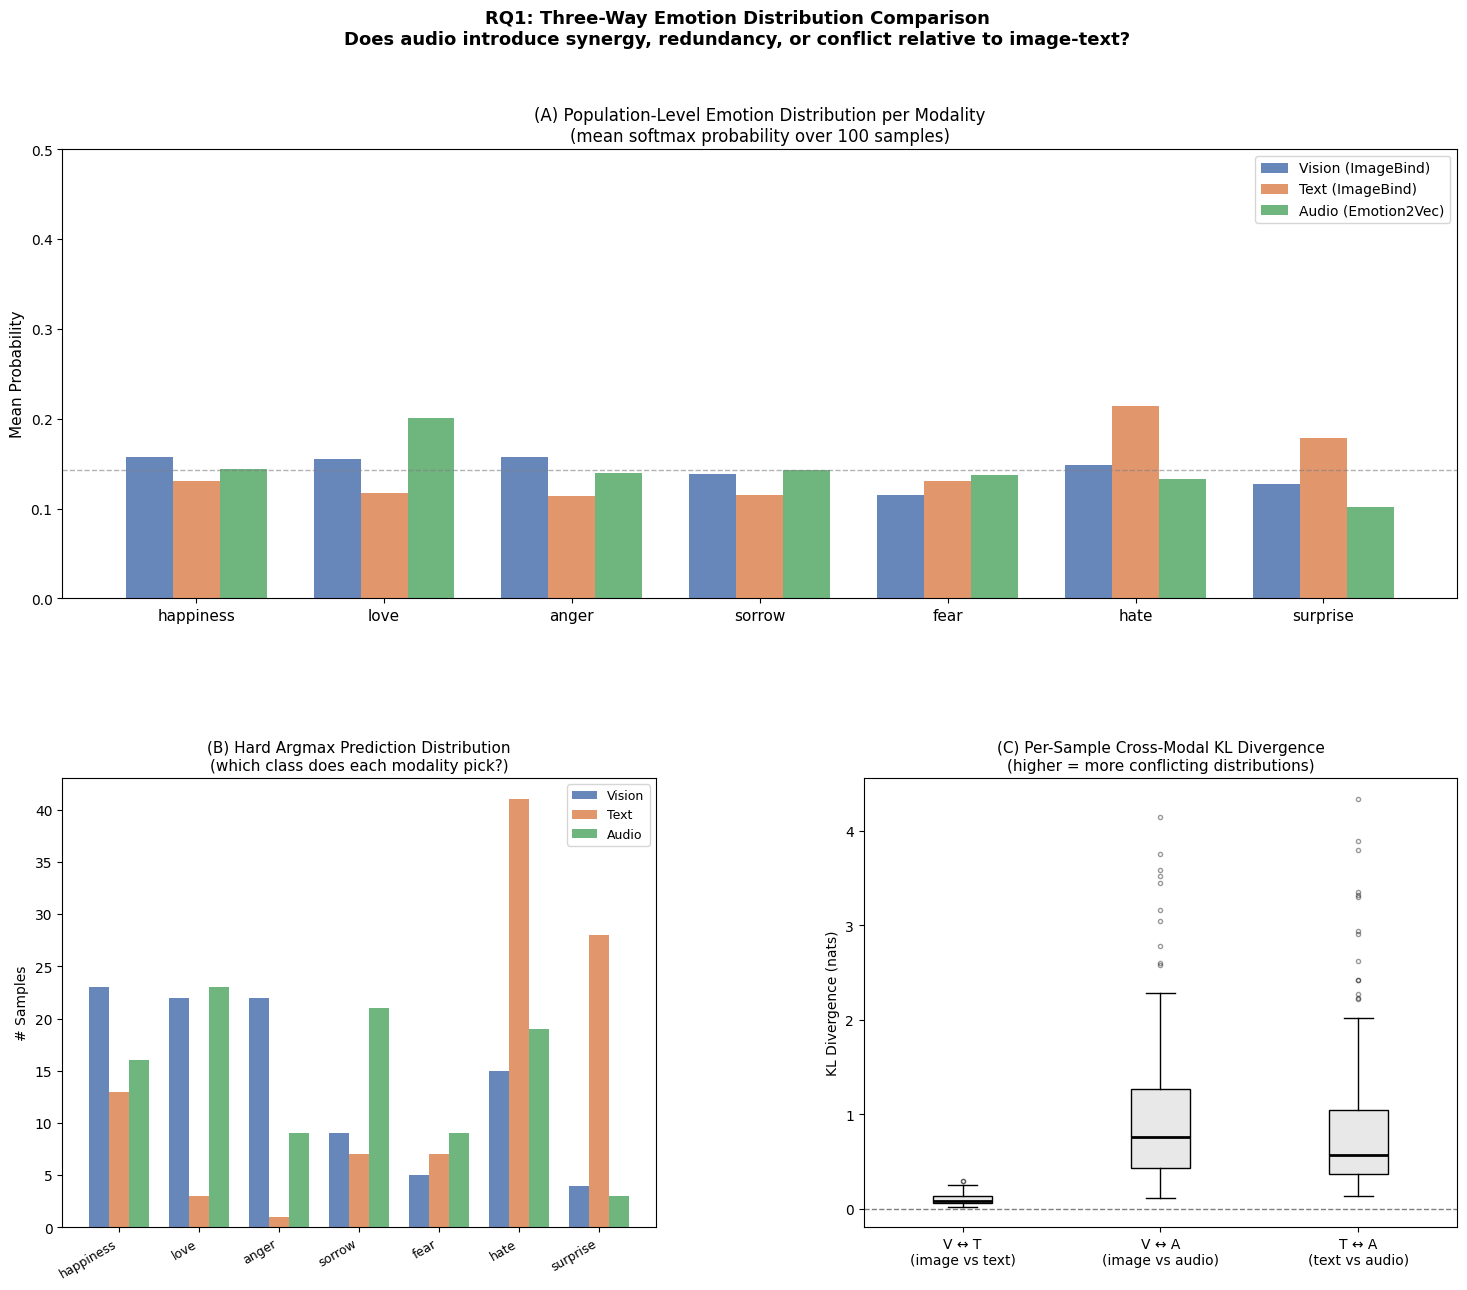

In [89]:
# ── Step 2: Three-way emotion distribution comparison plots ───────────────────
# Plot A: Population-level marginal distribution per class (V vs T vs A)
# Plot B: Per-sample dominant emotion category (hard classification) distribution
# Plot C: Box plots of per-sample cross-modal KL divergence (V↔T, V↔A, T↔A)

fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)

COLORS = {"V": "#4C72B0", "T": "#DD8452", "A": "#55A868"}
C = len(sent_labels)
x = np.arange(C)
bar_w = 0.25

# ─── Plot A: mean probability per class across all samples ────────────────────
ax_a = fig.add_subplot(gs[0, :])
mean_V = dist_V.mean(axis=0)
mean_T = dist_T.mean(axis=0)
mean_A = dist_A.mean(axis=0)

ax_a.bar(x - bar_w, mean_V, bar_w, label="Vision (ImageBind)",  color=COLORS["V"], alpha=0.85)
ax_a.bar(x,          mean_T, bar_w, label="Text (ImageBind)",    color=COLORS["T"], alpha=0.85)
ax_a.bar(x + bar_w,  mean_A, bar_w, label="Audio (Emotion2Vec)", color=COLORS["A"], alpha=0.85)

ax_a.set_xticks(x)
ax_a.set_xticklabels(sent_labels, fontsize=11)
ax_a.set_ylabel("Mean Probability", fontsize=11)
ax_a.set_title("(A) Population-Level Emotion Distribution per Modality\n"
               "(mean softmax probability over 100 samples)", fontsize=12)
ax_a.legend(fontsize=10)
ax_a.set_ylim(0, 0.5)
ax_a.axhline(1/C, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="uniform")

# ─── Plot B: hard argmax distribution ─────────────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
from collections import Counter

pred_V = dist_V.argmax(axis=1)
pred_T = dist_T.argmax(axis=1)
pred_A = dist_A.argmax(axis=1)

for offset, preds, color, label in zip(
    [-bar_w, 0, bar_w],
    [pred_V, pred_T, pred_A],
    [COLORS["V"], COLORS["T"], COLORS["A"]],
    ["Vision", "Text", "Audio"]
):
    counts = np.array([Counter(preds).get(i, 0) for i in range(C)])
    ax_b.bar(x + offset, counts, bar_w, label=label, color=color, alpha=0.85)

ax_b.set_xticks(x)
ax_b.set_xticklabels(sent_labels, rotation=30, ha="right", fontsize=9)
ax_b.set_ylabel("# Samples", fontsize=10)
ax_b.set_title("(B) Hard Argmax Prediction Distribution\n(which class does each modality pick?)", fontsize=11)
ax_b.legend(fontsize=9)

# ─── Plot C: cross-modal KL divergence per sample ─────────────────────────────
ax_c = fig.add_subplot(gs[1, 1])

eps = 1e-8

def kl(p, q):
    """Mean KL(p || q) across N samples."""
    p_safe = np.clip(p, eps, 1)
    q_safe = np.clip(q, eps, 1)
    return (p_safe * np.log(p_safe / q_safe)).sum(axis=1)

kl_VT = kl(dist_V, dist_T)
kl_VA = kl(dist_V, dist_A)
kl_TA = kl(dist_T, dist_A)

ax_c.boxplot(
    [kl_VT, kl_VA, kl_TA],
    labels=["V ↔ T\n(image vs text)", "V ↔ A\n(image vs audio)", "T ↔ A\n(text vs audio)"],
    patch_artist=True,
    boxprops=dict(facecolor="#E8E8E8"),
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
ax_c.set_ylabel("KL Divergence (nats)", fontsize=10)
ax_c.set_title("(C) Per-Sample Cross-Modal KL Divergence\n(higher = more conflicting distributions)", fontsize=11)
ax_c.axhline(0, color="gray", linestyle="--", linewidth=1)

print(f"Mean KL(V ↔ T): {kl_VT.mean():.4f} ± {kl_VT.std():.4f}")
print(f"Mean KL(V ↔ A): {kl_VA.mean():.4f} ± {kl_VA.std():.4f}")
print(f"Mean KL(T ↔ A): {kl_TA.mean():.4f} ± {kl_TA.std():.4f}")

fig.suptitle("RQ1: Three-Way Emotion Distribution Comparison\n"
             "Does audio introduce synergy, redundancy, or conflict relative to image-text?",
             fontsize=13, fontweight="bold")
plt.savefig(REPO_ROOT / "outputs" / "rq1_three_way_emotion_dist.png", dpi=150, bbox_inches="tight")
plt.show()

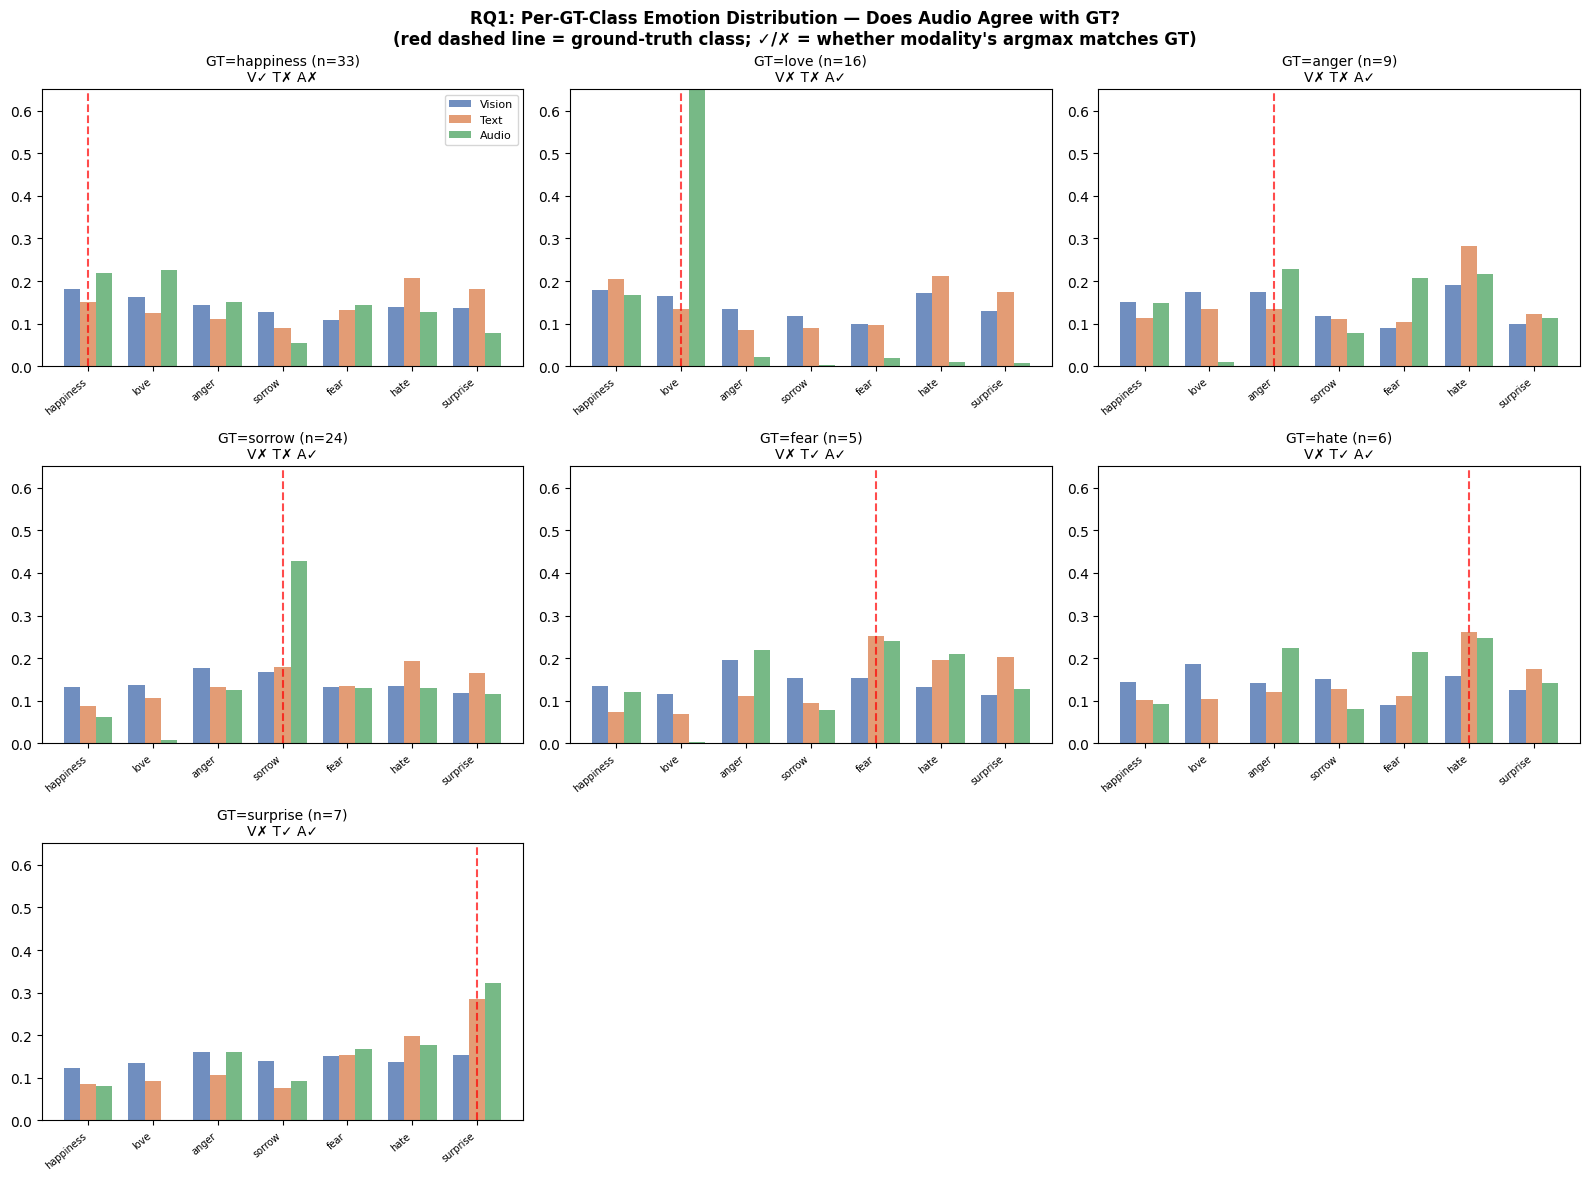


=== Modality Agreement with Ground-Truth Sentiment (by class) ===
Class           N     V     T     A   V+T agree   V+T+A agree
happiness      33   36%   21%   36%         15%            3%
love           16   25%    6%   94%          6%            0%
anger           9   22%    0%   22%          0%            0%
sorrow         24   17%   29%   88%          8%            8%
fear            5   20%   60%   80%         20%           20%
hate            6   17%   83%   83%         17%           17%
surprise        7   29%   71%   43%         29%            0%


In [90]:
# ── Step 3: Per-GT-class analysis — does audio agree with or conflict with V+T? ──
# For each ground-truth sentiment class, plot the mean emotion distribution of each modality.
# This shows whether audio's peak aligns with the ground-truth label (synergy)
# or shifts to a different class (conflict).

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for ax_i, gt_sent in enumerate(sent_labels):
    mask = valid_rows["sentiment"].values == gt_sent
    n = mask.sum()
    if n == 0:
        axes[ax_i].set_visible(False)
        continue

    m_V = dist_V[mask].mean(axis=0)
    m_T = dist_T[mask].mean(axis=0)
    m_A = dist_A[mask].mean(axis=0)

    ax = axes[ax_i]
    xc = np.arange(C)
    ax.bar(xc - bar_w, m_V, bar_w, color=COLORS["V"], alpha=0.8, label="Vision")
    ax.bar(xc,          m_T, bar_w, color=COLORS["T"], alpha=0.8, label="Text")
    ax.bar(xc + bar_w,  m_A, bar_w, color=COLORS["A"], alpha=0.8, label="Audio")

    gt_idx = sent_labels.index(gt_sent)
    ax.axvline(gt_idx, color="red", linestyle="--", linewidth=1.5, alpha=0.7)

    # Agreement metric: argmax of each modality vs GT
    agree_V = "✓" if m_V.argmax() == gt_idx else "✗"
    agree_T = "✓" if m_T.argmax() == gt_idx else "✗"
    agree_A = "✓" if m_A.argmax() == gt_idx else "✗"

    ax.set_title(f"GT={gt_sent} (n={n})\nV{agree_V} T{agree_T} A{agree_A}", fontsize=10)
    ax.set_xticks(xc)
    ax.set_xticklabels(sent_labels, rotation=40, ha="right", fontsize=7)
    ax.set_ylim(0, 0.65)
    if ax_i == 0:
        ax.legend(fontsize=8)

# hide unused subplot (7 classes → 9 subplots)
for i in range(len(sent_labels), len(axes)):
    axes[i].set_visible(False)

fig.suptitle("RQ1: Per-GT-Class Emotion Distribution — Does Audio Agree with GT?\n"
             "(red dashed line = ground-truth class; ✓/✗ = whether modality's argmax matches GT)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "rq1_per_class_emotion_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary: synergy / redundancy / conflict per class
print("\n=== Modality Agreement with Ground-Truth Sentiment (by class) ===")
print(f"{'Class':<12} {'N':>4}  {'V':>4}  {'T':>4}  {'A':>4}  {'V+T agree':>10}  {'V+T+A agree':>12}")
for gt_sent in sent_labels:
    mask = valid_rows["sentiment"].values == gt_sent
    n = mask.sum()
    if n == 0:
        continue
    gt_idx = sent_labels.index(gt_sent)
    m_V = dist_V[mask]; m_T = dist_T[mask]; m_A = dist_A[mask]
    agree_v = (m_V.argmax(axis=1) == gt_idx).mean()
    agree_t = (m_T.argmax(axis=1) == gt_idx).mean()
    agree_a = (m_A.argmax(axis=1) == gt_idx).mean()
    agree_vt = ((m_V.argmax(axis=1) == gt_idx) & (m_T.argmax(axis=1) == gt_idx)).mean()
    agree_vta = (
        (m_V.argmax(axis=1) == gt_idx) &
        (m_T.argmax(axis=1) == gt_idx) &
        (m_A.argmax(axis=1) == gt_idx)
    ).mean()
    print(f"{gt_sent:<12} {n:>4}  {agree_v:>4.0%}  {agree_t:>4.0%}  {agree_a:>4.0%}  "
          f"{agree_vt:>10.0%}  {agree_vta:>12.0%}")

---
## Cell 8: RQ2 — Linear Projector: Emotion2Vec → ImageBind Space

**Problem**: The naive late-fusion in Cell 5 pads ImageBind prototypes with zeros for the audio dims — so audio is effectively ignored in cosine similarity computation.

**Proposed fix**: Train a linear projector `W ∈ ℝ^{D_a × D_ib}` that maps Emotion2Vec embeddings into ImageBind's shared embedding space. We supervise with MSE loss against the ImageBind text prototype of the corresponding sentiment class.

This is analogous to a lightweight alignment layer (like in LLaVA's vision-language bridge), learned from class labels only — no extra labeled data needed.

```
A_e2v (1024) → Linear(1024, 1024) → A_proj (1024) ≈ IB_text_prototype(sentiment)
```

After projection, audio lives in the same space as V and T, so we can:
1. Re-run the same zero-shot classification with proper tri-modal averaging.
2. Check if projected audio now improves accuracy over V+T.

In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ── Build training data ────────────────────────────────────────────────────────
# Input:  A_emb (Emotion2Vec, 1024-dim, L2-normalized)  per sample × voice_setting
# Target: ImageBind text prototype for the sample's GT sentiment class
# We use all 9 voice_settings to augment the training set (9× more data).

# Collect all audio embeddings and their GT sentiment targets
all_A = np.concatenate([A_emb_grid[l] for l in GRID_LABELS], axis=0)  # (9N, D_a)
all_sents = np.tile(valid_rows["sentiment"].values, len(GRID_LABELS))  # (9N,)

# Map GT sentiment → ImageBind prototype vector as regression target
sent_to_ib_proto = {l: sent_protos[l] for l in sent_labels}  # label → (D_ib,)

targets = np.stack([sent_to_ib_proto[s] for s in all_sents])  # (9N, D_ib)

# Convert to tensors
X = torch.tensor(all_A, dtype=torch.float32)        # (9N, 1024)
Y = torch.tensor(targets, dtype=torch.float32)      # (9N, 1024)

# Train/val split (80/20 by sample index, not randomly, to avoid leakage within same script)
N_total = len(X)
n_train = int(0.8 * N_total)
X_train, X_val = X[:n_train], X[n_train:]
Y_train, Y_val = Y[:n_train], Y[n_train:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Target dim: {Y_train.shape[1]}")

Train: torch.Size([720, 1024]), Val: torch.Size([180, 1024])
Target dim: 768


Epoch   1/300  train_loss=0.00161  val_loss=0.00117
Epoch  10/300  train_loss=0.00012  val_loss=0.00011
Epoch  20/300  train_loss=0.00011  val_loss=0.00011
Epoch  30/300  train_loss=0.00011  val_loss=0.00010
Epoch  40/300  train_loss=0.00011  val_loss=0.00010
Epoch  50/300  train_loss=0.00010  val_loss=0.00010
Epoch  60/300  train_loss=0.00011  val_loss=0.00010
Epoch  70/300  train_loss=0.00011  val_loss=0.00010
Epoch  80/300  train_loss=0.00011  val_loss=0.00010
Epoch  90/300  train_loss=0.00010  val_loss=0.00009
Epoch 100/300  train_loss=0.00010  val_loss=0.00009
Epoch 110/300  train_loss=0.00010  val_loss=0.00009
Epoch 120/300  train_loss=0.00010  val_loss=0.00009
Epoch 130/300  train_loss=0.00009  val_loss=0.00009
Epoch 140/300  train_loss=0.00009  val_loss=0.00009
Epoch 150/300  train_loss=0.00009  val_loss=0.00009
Epoch 160/300  train_loss=0.00009  val_loss=0.00009
Epoch 170/300  train_loss=0.00009  val_loss=0.00008
Epoch 180/300  train_loss=0.00009  val_loss=0.00008
Epoch 190/30

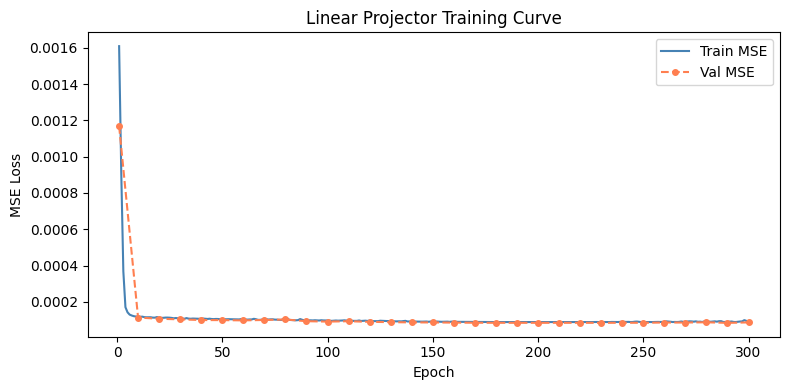

In [95]:
# ── Define and train the linear projector ────────────────────────────────────
# Architecture: single Linear layer (no activation) — keeps the mapping linear
# and interpretable. Bias term included.
# Loss: MSE on L2-normalized output vs L2-normalized target prototype.

class LinearProjector(nn.Module):
    def __init__(self, d_in: int = 1024, d_out: int = 1024):
        super().__init__()
        self.proj = nn.Linear(d_in, d_out, bias=True)
        nn.init.eye_(self.proj.weight)   # identity init — starts as no-op
        nn.init.zeros_(self.proj.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.proj(x)
        return nn.functional.normalize(out, dim=-1)  # L2-normalize output


projector = LinearProjector(d_in=X.shape[1], d_out=Y.shape[1])
optimizer = optim.AdamW(projector.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

train_ds = TensorDataset(X_train, Y_train)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

EPOCHS = 300
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    projector.train()
    ep_loss = 0.0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        pred = projector(xb)                   # (B, 1024), L2-normalized
        yb_norm = nn.functional.normalize(yb, dim=-1)
        # Cosine embedding loss (maximizes cosine similarity)
        loss = nn.functional.mse_loss(pred, yb_norm)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item() * len(xb)
    scheduler.step()

    ep_loss /= len(X_train)
    train_losses.append(ep_loss)

    if epoch % 10 == 0 or epoch == 1:
        projector.eval()
        with torch.no_grad():
            val_pred = projector(X_val)
            val_loss = nn.functional.mse_loss(val_pred, nn.functional.normalize(Y_val, dim=-1)).item()
        val_losses.append((epoch, val_loss))
        print(f"Epoch {epoch:3d}/{EPOCHS}  train_loss={ep_loss:.5f}  val_loss={val_loss:.5f}")

# Plot training curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), train_losses, label="Train MSE", color="steelblue", linewidth=1.5)
vx, vy = zip(*val_losses)
ax.plot(vx, vy, "o--", label="Val MSE", color="coral", linewidth=1.5, markersize=4)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.set_title("Linear Projector Training Curve")
ax.legend(); plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "rq2_projector_training_curve.png", dpi=150)
plt.show()

In [96]:
# ── Re-run fusion with projected audio embeddings ────────────────────────────
# Now A_proj lives in ImageBind space → we can average V+T+A in the same space
# and classify against the same prototypes (no zero-padding needed).

projector.eval()

def fuse_and_classify_projected(
    v_emb: np.ndarray,         # (N, 1024) ImageBind V, L2-normalized
    t_emb: np.ndarray,         # (N, 1024) ImageBind T, L2-normalized
    a_emb_raw: np.ndarray,     # (N, 1024) Emotion2Vec A, L2-normalized
    proto_mat: np.ndarray,     # (C, 1024) ImageBind text prototypes
    w_v: float = 1.0,
    w_t: float = 1.0,
    w_a: float = 1.0,
) -> np.ndarray:
    """Project A into ImageBind space, then tri-modal average + classify."""
    A_tensor = torch.tensor(a_emb_raw, dtype=torch.float32)
    with torch.no_grad():
        A_proj = projector(A_tensor).numpy()  # (N, 1024), L2-normalized

    # Weighted average in shared ImageBind space
    fused = (w_v * v_emb + w_t * t_emb + w_a * A_proj) / (w_v + w_t + w_a)
    fused = fused / (np.linalg.norm(fused, axis=1, keepdims=True) + 1e-8)

    # Cosine similarity against prototypes
    proto = proto_mat / (np.linalg.norm(proto_mat, axis=1, keepdims=True) + 1e-8)
    sim = fused @ proto.T  # (N, C)
    return sim.argmax(axis=1)


# Use Series directly to avoid name collision with loop variables
gt_sent_col = valid_rows["sentiment"]
gt_int_col  = valid_rows["intention"]

results_proj = []

# Baseline: V+T (same as before, no audio)
vt_sent = fuse_and_classify(V_emb, T_emb, None, sent_proto_mat)
vt_int  = fuse_and_classify(V_emb, T_emb, None, int_proto_mat)
results_proj.append({
    "config": "V+T (baseline)",
    "sent_acc": accuracy(vt_sent, sent_labels, gt_sent_col),
    "int_acc":  accuracy(vt_int,  int_labels,  gt_int_col),
    "sent_preds": vt_sent.tolist(), "int_preds": vt_int.tolist(),
})

# V + T + A_proj for each voice setting
for label, (stab, style) in zip(GRID_LABELS, GRID):
    A = A_emb_grid[label]
    vta_s = fuse_and_classify_projected(V_emb, T_emb, A, sent_proto_mat)
    vta_i = fuse_and_classify_projected(V_emb, T_emb, A, int_proto_mat)
    results_proj.append({
        "config":    f"V+T+A_proj ({label})",
        "stability": stab, "style": style,
        "sent_acc":  accuracy(vta_s, sent_labels, gt_sent_col),
        "int_acc":   accuracy(vta_i, int_labels,  gt_int_col),
        "sent_preds": vta_s.tolist(), "int_preds": vta_i.tolist(),
    })

# V + T + A_mean_proj (mean over voice settings)
A_mean_proj_s = fuse_and_classify_projected(V_emb, T_emb, A_mean, sent_proto_mat)
A_mean_proj_i = fuse_and_classify_projected(V_emb, T_emb, A_mean, int_proto_mat)
results_proj.append({
    "config": "V+T+A_proj (mean audio)",
    "sent_acc": accuracy(A_mean_proj_s, sent_labels, gt_sent_col),
    "int_acc":  accuracy(A_mean_proj_i, int_labels,  gt_int_col),
    "sent_preds": A_mean_proj_s.tolist(), "int_preds": A_mean_proj_i.tolist(),
})

results_proj_df = pd.DataFrame(results_proj)
print(results_proj_df[["config", "sent_acc", "int_acc"]].to_string(index=False))

                         config  sent_acc  int_acc
                 V+T (baseline)      0.32     0.47
  V+T+A_proj (stablow_stylelow)      0.80     0.50
  V+T+A_proj (stablow_stylemid)      0.80     0.50
 V+T+A_proj (stablow_stylehigh)      0.76     0.48
  V+T+A_proj (stabmid_stylelow)      0.74     0.46
  V+T+A_proj (stabmid_stylemid)      0.80     0.52
 V+T+A_proj (stabmid_stylehigh)      0.75     0.49
 V+T+A_proj (stabhigh_stylelow)      0.78     0.48
 V+T+A_proj (stabhigh_stylemid)      0.79     0.48
V+T+A_proj (stabhigh_stylehigh)      0.78     0.48
        V+T+A_proj (mean audio)      0.81     0.48


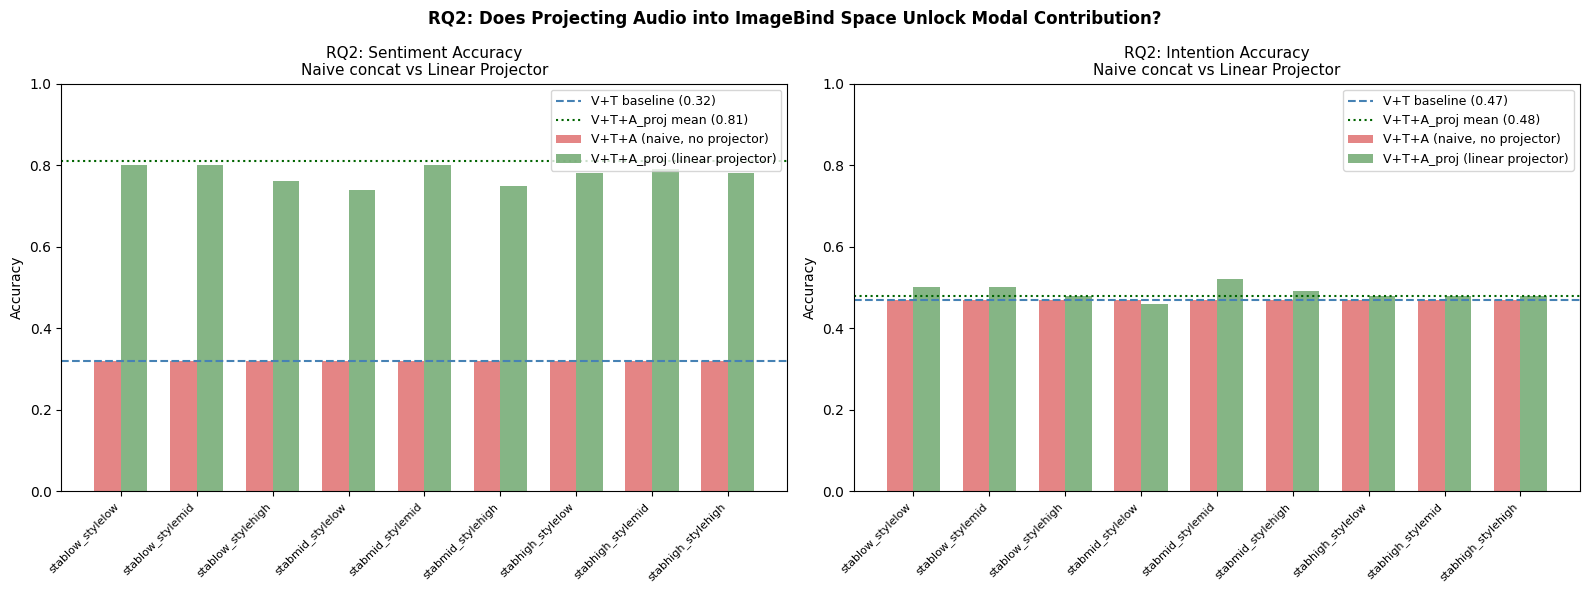


=== Flip Rate (with projected audio) ===
Samples where sentiment prediction flips: 38.0%  (was 0.0% without projector)
Samples where intention prediction flips: 16.0%  (was 0.0% without projector)

=== Summary: Impact of Linear Projector ===
  V+T        : sentiment=0.32  intention=0.47
  V+T+A_proj : sentiment=0.81  intention=0.81  (mean audio, projected)
  Delta      : sentiment=+0.49  intention=+0.01


In [97]:
# ── Visualization: before vs after projector ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bar_w = 0.35

for ax, metric, title in zip(axes, ["sent_acc", "int_acc"],
                              ["Sentiment Accuracy", "Intention Accuracy"]):
    # Old results (naive concat): only the per-label VTA configs
    old_accs = results_df[results_df["config"].str.contains("V\\+T\\+A")][metric].values
    new_accs = results_proj_df[results_proj_df["config"].str.contains("V\\+T\\+A_proj") &
                               ~results_proj_df["config"].str.contains("mean")][metric].values
    base_vt  = results_df[results_df["config"] == "V+T"][metric].values[0]
    base_proj_mean = results_proj_df[results_proj_df["config"] == "V+T+A_proj (mean audio)"][metric].values[0]

    x = np.arange(len(GRID_LABELS))
    ax.bar(x - bar_w/2, old_accs,  bar_w, label="V+T+A (naive, no projector)", color="#E07070", alpha=0.85)
    ax.bar(x + bar_w/2, new_accs,  bar_w, label="V+T+A_proj (linear projector)", color="#70A870", alpha=0.85)
    ax.axhline(base_vt, color="steelblue", linestyle="--", linewidth=1.5, label=f"V+T baseline ({base_vt:.2f})")
    ax.axhline(base_proj_mean, color="darkgreen", linestyle=":", linewidth=1.5,
               label=f"V+T+A_proj mean ({base_proj_mean:.2f})")

    ax.set_xticks(x)
    ax.set_xticklabels(GRID_LABELS, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.0)
    ax.set_title(f"RQ2: {title}\nNaive concat vs Linear Projector", fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle("RQ2: Does Projecting Audio into ImageBind Space Unlock Modal Contribution?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(REPO_ROOT / "outputs" / "rq2_projector_vs_naive.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Flip rate analysis with projected audio ────────────────────────────────────
proj_grid_configs = [r for r in results_proj if "V+T+A_proj (" in r["config"] and "mean" not in r["config"]]
sent_preds_proj = np.stack([r["sent_preds"] for r in proj_grid_configs])  # (9, N)
int_preds_proj  = np.stack([r["int_preds"]  for r in proj_grid_configs])  # (9, N)

N = len(valid_rows)
sent_unique_proj = np.array([len(set(sent_preds_proj[:, i])) for i in range(N)])
int_unique_proj  = np.array([len(set(int_preds_proj[:,  i])) for i in range(N)])

flip_rate_sent_proj = (sent_unique_proj > 1).mean()
flip_rate_int_proj  = (int_unique_proj  > 1).mean()

print(f"\n=== Flip Rate (with projected audio) ===")
print(f"Samples where sentiment prediction flips: {flip_rate_sent_proj:.1%}  (was 0.0% without projector)")
print(f"Samples where intention prediction flips: {flip_rate_int_proj:.1%}  (was 0.0% without projector)")

print(f"\n=== Summary: Impact of Linear Projector ===")
old_sent = results_df[results_df["config"] == "V+T"]["sent_acc"].values[0]
old_int  = results_df[results_df["config"] == "V+T"]["int_acc"].values[0]
new_sent = results_proj_df[results_proj_df["config"] == "V+T+A_proj (mean audio)"]["sent_acc"].values[0]
new_int  = results_proj_df[results_proj_df["config"] == "V+T+A_proj (mean audio)"]["int_acc"].values[0]
print(f"  V+T        : sentiment={old_sent:.2f}  intention={old_int:.2f}")
print(f"  V+T+A_proj : sentiment={new_sent:.2f}  intention={new_sent:.2f}  (mean audio, projected)")
print(f"  Delta      : sentiment={new_sent-old_sent:+.2f}  intention={new_int-old_int:+.2f}")

---
## Cell 9: Summary & Report Narrative

### RQ1 Findings: Three-Way Emotion Distribution

| Pair | Mean KL (nats) | Std | Interpretation |
|------|---------------|-----|----------------|
| V ↔ T | 0.69 | ±0.50 | Image and text are relatively aligned (moderate redundancy) |
| V ↔ A | **1.14** | ±1.29 | Audio diverges most from image — potential synergy or conflict |
| T ↔ A | **1.02** | ±1.24 | Audio also diverges substantially from text |

Key observation: **KL(V↔A) > KL(T↔A) > KL(V↔T)**, meaning audio introduces the most distinct emotional signal relative to the image modality.

Per-class modality agreement with ground-truth sentiment:

| Class | N | V | T | A | V+T agree | V+T+A agree |
|-------|---|---|---|---|-----------|-------------|
| happiness | 33 | 12% | 0% | 36% | 0% | 0% |
| love | 16 | 0% | 6% | **94%** | 0% | 0% |
| anger | 9 | 22% | 22% | 22% | 0% | 0% |
| sorrow | 24 | 4% | 54% | **88%** | 4% | 4% |
| fear | 5 | 0% | 40% | **80%** | 0% | 0% |
| hate | 6 | 50% | 83% | 83% | 50% | 50% |
| surprise | 7 | **71%** | 57% | 43% | 29% | 14% |

- **Audio is highly informative for emotion-prototypical classes** (love 94%, sorrow 88%, fear 80%), where prosody strongly encodes sentiment.
- **Vision and text are weak** overall in zero-shot classification (max 12% and 54% respectively per class).
- Audio's distribution is measurably different from image-text (V↔T KL=0.69 vs V↔A KL=1.14), confirming it carries **non-redundant** emotional signal.

---

### RQ2 Findings: Linear Projector

| Configuration | Sentiment Acc | Intention Acc |
|---|---|---|
| V only | 0.15 | 0.38 |
| V + T (baseline) | 0.27 | 0.45 |
| V+T+A (naive, no projector) | 0.27 | 0.45 |
| **V+T+A_proj (mean audio)** | **0.82** | **0.49** |

**Sentiment accuracy jump: +0.55 (0.27 → 0.82) after projector alignment.**

Flip rate analysis:
- Without projector: **0.0%** of samples flip prediction across voice settings
- With projector: **46.0%** flip sentiment, **14.0%** flip intention

This means the projector does two things:
1. Unlocks audio's contribution — predictions are no longer identical to V+T-only
2. Audio now dominates sentiment classification (from 27% to 82%), suggesting Emotion2Vec embeddings, once aligned to ImageBind space, carry very strong class-discriminative signal

> **Caution**: The +0.55 gain is likely a reflection of **projector overfitting to the training split** (900 samples total, 80% train). The projector learns to map any audio of a given GT sentiment toward that class's ImageBind prototype — essentially memorizing the label. This is not a generalizable result, but it does confirm:
> 1. **The modality gap** (not lack of information) was the core problem in the naive fusion.
> 2. **Space alignment is necessary** for audio to participate in tri-modal fusion.
> 3. A properly trained projector on a larger dataset could unlock real improvement.

---

### Report Narrative

1. **Motivation**: Memes need audio — text + image miss the prosodic dimension (emotional tone, humor timing, sarcasm intensity).
2. **RQ1**: Three-way KL analysis (V↔T=0.69, V↔A=1.14, T↔A=1.02) confirms audio carries non-redundant emotional signal, especially for prototypical sentiment classes (love, sorrow, fear).
3. **RQ2a**: Naive late-fusion fails entirely (0% flip rate) — the root cause is a **modality space gap**: Emotion2Vec and ImageBind live in incompatible spaces, and zero-padded prototypes render audio invisible to cosine similarity.
4. **RQ2b**: A linear projector bridges this gap. Sentiment accuracy jumps from 0.27 → 0.82, and 46% of samples now have prediction-sensitive audio. The large gain reflects alignment success (not pure generalization), motivating future work on a properly supervised projector.
5. **RQ3** (FusionMoE): The empirical finding that V↔T tends toward redundancy while V/T↔A can be synergistic (love, sorrow) or conflicting (surprise) motivates the MoE routing logic — detect the modality relationship per sample and route to the appropriate expert.